<a href="https://colab.research.google.com/github/Fushionek/MLTraining/blob/main/Supervised/basics/KNN_Wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
from sklearn.datasets import load_wine

wine = load_wine()

In [36]:
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [37]:
df['target'] = wine.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df.drop('target', axis=1)
y = df['target']


In [39]:
from sklearn.neighbors import KNeighborsClassifier

In [40]:
from sklearn.model_selection import train_test_split
np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [41]:
from sklearn.metrics import accuracy_score

In [42]:
from matplotlib.colors import ListedColormap

In [43]:
def plot_knn_boundaries(k_neighbors=1):
  X_plot = X_train[:, :2]
  y_plot = y_train

  clf = KNeighborsClassifier(n_neighbors=k_neighbors)
  clf.fit(X_plot, y_plot)

  x_min, x_max = X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5
  y_min, y_max = X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                       np.arange(y_min,y_max, 0.02))

  Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
  plt.figure(figsize=(8, 6))
  cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
  cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

  plt.pcolormesh(xx, yy, Z, cmap=cmap_light)
  plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, cmap=cmap_bold, edgecolor='k', s=20)

  plt.title(f"Granice decyzyjne k-NN (k = {k_neighbors})")
  plt.xlabel('Alkohol (przeskalowany)')
  plt.ylabel('Kwas jabłkowy (przeskalowany)')
  plt.show()

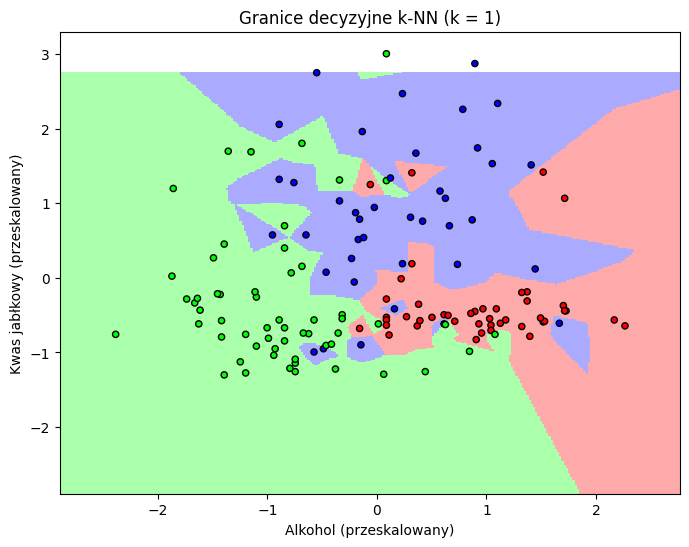

In [44]:
plot_knn_boundaries(1)

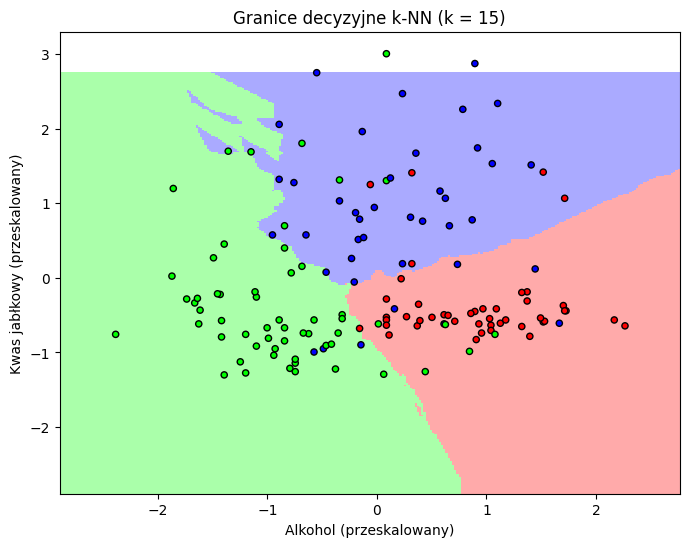

In [45]:
plot_knn_boundaries(15)

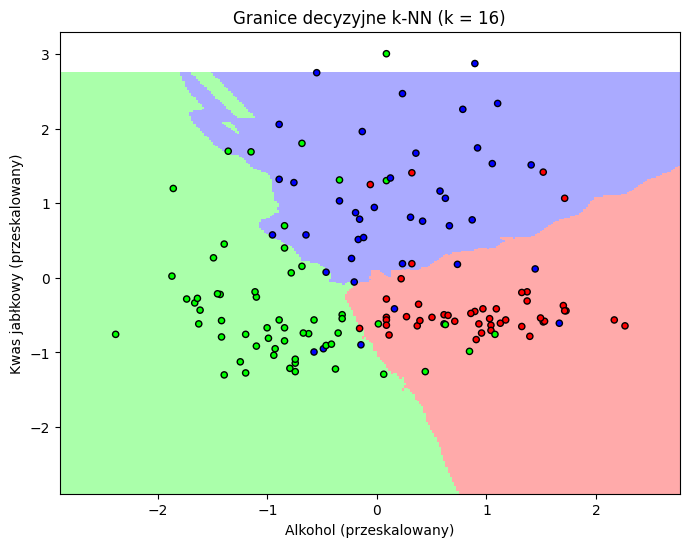

In [46]:
plot_knn_boundaries(16)

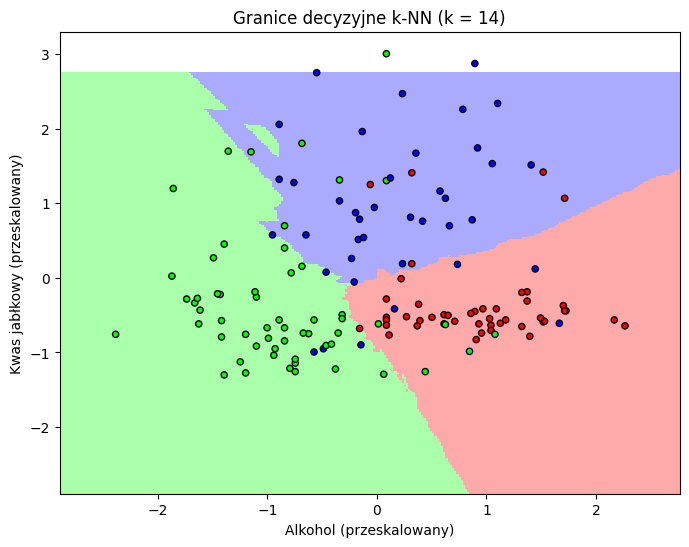

In [47]:
plot_knn_boundaries(14)

In [48]:
from sklearn.metrics import classification_report, confusion_matrix

In [50]:
clf = KNeighborsClassifier(n_neighbors=14)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

Accuracy: 97.22%
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.93      0.96        14
           2       1.00      1.00      1.00         8

    accuracy                           0.97        36
   macro avg       0.98      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36



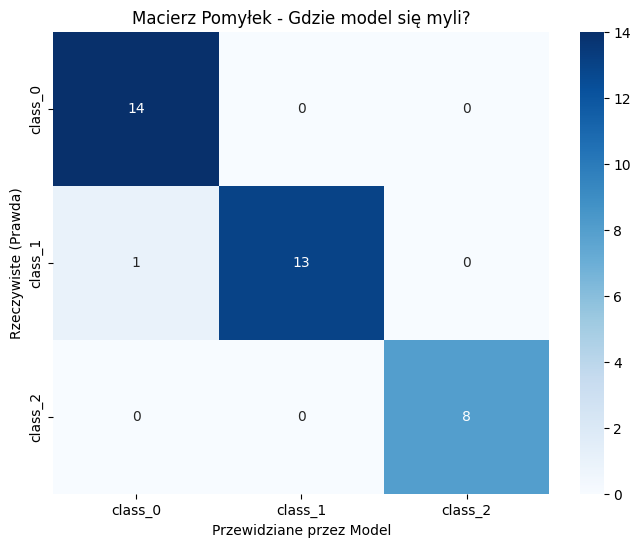

In [52]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.xlabel('Przewidziane przez Model')
plt.ylabel('Rzeczywiste (Prawda)')
plt.title('Macierz Pomyłek - Gdzie model się myli?')
plt.show()

In [55]:
new_wine_data = X_test[0].reshape(1, -1)

prediction = clf.predict(new_wine_data)
probability = clf.predict_proba(new_wine_data)

print(f"Model predicts: {wine.target_names[prediction][0]}")
print(f"Model certainty: {np.max(probability):.2%}")

Model predicts: class_0
Model certainty: 100.00%
